# Image Segmentation

* 2D image segmentation model
* 

In [ ]:
# GPU
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '7'


In [ ]:
# library import
import numpy as np
import torch
import torchvision.models as tv_models
import matplotlib.pyplot as plt
import cv2
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models._utils import IntermediateLayerGetter

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 1. Data

### 1.1 Data Preprocessing

* 기본 사용:
    * ISBI 2012: brainiac2


* 변형 사용
    * multi class
        * /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/bhsd
        * /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/mbhseg25
        * /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/bhx(원본 CQ500 Dicom 참조 필요)

    * single class
        * /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data/ct_ich
        * SNU HE-01


In [34]:
# ISBI 2012
DATA_DIR = "/home/jovyan/aicon-gamma-datavol-1/hjgoh/ai-lab/segmentation/unet/data/isbi-2012"

In [35]:
# stack load + 분할

# 30장 512x512 unit8 multiframe tifs
# 분할비 train : val : test = 21 : 3 : 6 / 순서대로 분할 
# 이진 마스크 레이블

def load_tif_stack(path):
    # path check
    img = Image.open(path)
    frames = [np.array (img.seek(i) or img) for i in range(img.n_frames)]
    return np.stack(frames, axis=0) # [N, H, W ]

volumes = load_tif_stack(os.path.join(DATA_DIR, "train-volume.tif")) #[30, 512, 512]
labels = load_tif_stack(os.path.join(DATA_DIR, "train-label.tif")) #[30, 512, 512]

N = volumes.shape[0]
train_end = int(N * 0.7)  # 21
val_end = int(N * 0.8)   # 24

train_idx = list(range(0, train_end))       # 0~20
val_idx = list(range(train_end, val_end))   # 21~23
test_idx = list(range(val_end, N))          # 24~29

print(f"train_idx: {train_idx}")
print(f"val_idx: {val_idx}")
print(f"test_idx: {test_idx}")
    

train_idx: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
val_idx: [21, 22, 23]
test_idx: [24, 25, 26, 27, 28, 29]


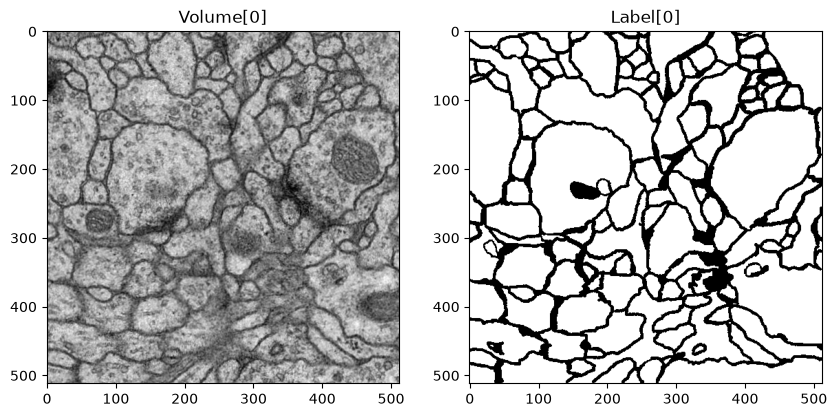

In [36]:
# 라벨 의미 확인
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(volumes[0], cmap='gray')
axes[0].set_title("Volume[0]")
axes[1].imshow(labels[0], cmap='gray')
axes[1].set_title("Label[0]")
plt.show()

### 1.2 Data Loader

In [37]:
class ISBIDataset(Dataset):
    def __init__(self, volumes, labels, indices, transform=None):
        self.volumes = volumes
        self.labels = labels
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        i = self.indices[idx]
        image = Image.fromarray(self.volumes[i])
        mask = Image.fromarray(self.labels[i])
        if self.transform: 
            image, mask = self.transform(image, mask)
        return image, mask # PIL image, mask

### 1.3 Data Transform

In [38]:
def elastic_deformation(image, mask, grid_size=3, sigma=10, rng=None):
    # np array 기반의 변형
    # 3x3 coarse grid에 N(0, sigma) 변위 샘플 
    # -> bicubic 보간으로 dense displacement field 생성 -> warp
    rng = rng or np.random
    h, w = image.shape[:2]

    # 1. 3x3 coarse grid 변위 샘플 (x, y 방향 각각 독립)
    dx_coarse = rng.normal(0, sigma, size=(grid_size, grid_size)).astype(np.float32)
    dy_coarse = rng.normal(0, sigma, size=(grid_size, grid_size)).astype(np.float32)

    # 2. bicubic 보간으로 (h, w) 크기 dense field로 업샘플링
    dx = cv2.resize(dx_coarse, (w, h), interpolation=cv2.INTER_CUBIC)
    dy = cv2.resize(dy_coarse, (w, h), interpolation=cv2.INTER_CUBIC)

    # 3. 픽셀 좌표 + 변위 -> remap으로 warp
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    map_x = (x + dx).astype(np.float32)
    map_y = (y + dy).astype(np.float32)

    # image는 bicubic(부드러운 보간), mask는 nearest(라벨 값이 섞이면 안 되므로)
    image_deformed = cv2.remap(image, map_x, map_y, interpolation=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REFLECT)
    mask_deformed  = cv2.remap(mask,  map_x, map_y, interpolation=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)

    return image_deformed, mask_deformed

In [39]:
class ISBITransform:
    def __init__(self, train=False):
        self.train = train

    def __call__(self, image, mask): 
        image = np.array(image)
        mask = np.array(mask)

        if self.train:
            # elastic deformation 
            if torch.rand(1).item() > 0.5: # 증강 옵션 랜덤 결정
                image, mask = elastic_deformation(image, mask)

        image = transforms.functional.to_tensor(image)   # [1, H, W], 0~1
        mask = torch.as_tensor(mask, dtype=torch.long)
        mask = (mask > 127).long()                      # 0, 1로 변형

        return image, mask # torch tensor

### 1.4 최종 data 조합

In [40]:
BATCH_SIZE = 4

In [41]:
train_ds = ISBIDataset(volumes, labels, train_idx, transform=ISBITransform(train=True))
val_ds   = ISBIDataset(volumes, labels, val_idx,   transform=ISBITransform(train=False))
test_ds  = ISBIDataset(volumes, labels, test_idx,  transform=ISBITransform(train=False))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

In [42]:
# 확인
images, masks = next(iter(train_loader))

print("images:", images.shape, images.dtype, images.min().item(), images.max().item())
print("masks: ", masks.shape, masks.dtype, masks.min().item(), masks.max().item())
print("mask unique values:", torch.unique(masks))

images: torch.Size([4, 1, 512, 512]) torch.float32 0.0 1.0
masks:  torch.Size([4, 512, 512]) torch.int64 0 1
mask unique values: tensor([0, 1])


In [43]:
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    total = sum(x[0].size(0) for x in loader)
    print(f"{name}: {len(loader)} batches, {total} samples")

train: 6 batches, 21 samples
val: 1 batches, 3 samples
test: 2 batches, 6 samples


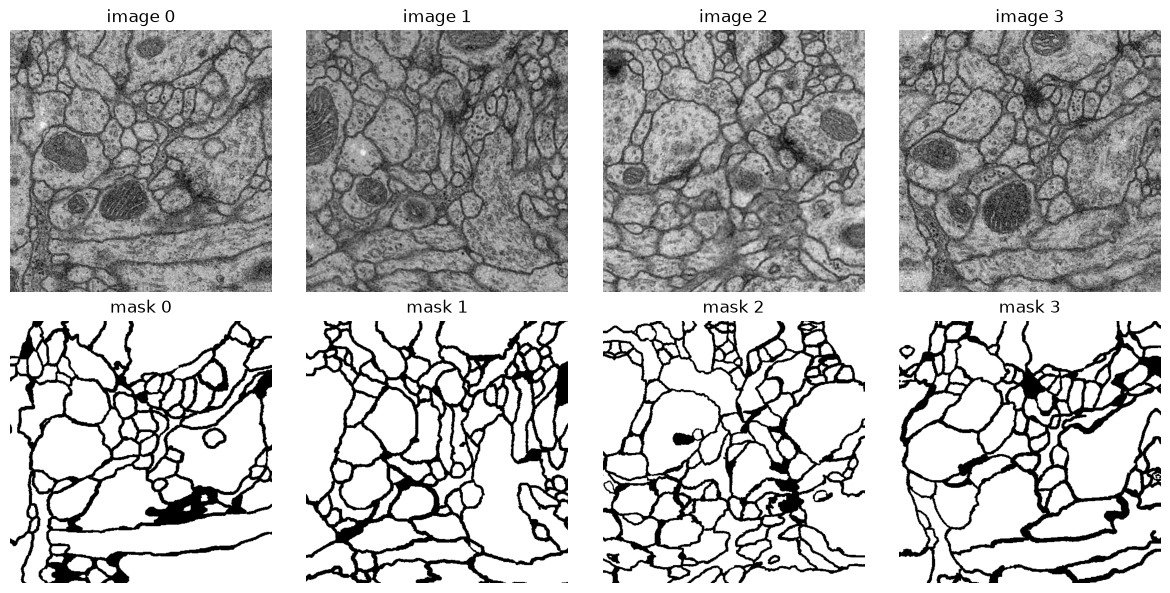

In [44]:
import matplotlib.pyplot as plt

images, masks = next(iter(train_loader))

fig, axes = plt.subplots(2, min(4, images.size(0)), figsize=(12, 6))
for i in range(min(4, images.size(0))):
    axes[0, i].imshow(images[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title(f"image {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(masks[i].numpy(), cmap='gray')
    axes[1, i].set_title(f"mask {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 2.Model

* encoder + decoder
* skip connection: encoder feature > decoder
* 원 논문 입력크기: 572x572 -> 388x388
    * overlap-tile strategy: 추론 입력 이미지의 가장자리를 반사 패딩해서 늘려 넣기 / 출력이 원하는 크기가 되도록 역산해서 입력 패딩량 계산
    * 학습 loss 계산: GT mask도 out_conv의 출력 크기에 맞춰서 centor crop해서 비교 

### 2.1 Encoder 

#### 2.1.1 Conv Block

In [45]:
class ConvBlock(nn.Module):
    """3x3 valid conv x2 + ReLU (원 논문 방식, padding 없음)"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3)

        self.bn1 = nn.BatchNorm2d(out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.relu = nn.ReLU(inplace=True)  

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

#### 2.1.2 Encoder Block

In [52]:
class EncoderBlock(nn.Module):
    # copy and crop(2x ConvBlock) + maxpooling
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.conv(x)
        pooled = self.pool(skip)        
        return skip, pooled

### 2.2 Bridge

* encoder 마지막 - decoder 시작 사이의 bottleneck

In [53]:
class Bridge(nn.Module):
    """encoder 마지막 - decoder 시작 사이의 bottleneck"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)

    def forward(self, x):
        return self.conv(x)

### 2.3 Decoder

In [48]:
def center_crop(enc_feat, target_hw):
    _, _, h, w = enc_feat.size()
    th, tw = target_hw
    dh = (h - th) // 2
    dw = (w - tw) // 2
    return enc_feat[:, :, dh:dh+th, dw:dw+tw]

In [49]:
class DecoderBlock(nn.Module):
    """upconv(2x2,stride2) + skip center-crop + concat + ConvBlock"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.upconv = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_ch, out_ch) # concat 후의 채널

    def forward(self, x, skip):
        x = self.upconv(x)
        skip = center_crop(skip, x.size()[2:])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

### 2.4 Model

In [55]:
class UNet(nn.Module):
    def __init__(self, in_ch=1, num_classes=2):
        super().__init__()
        self.enc1 = EncoderBlock(in_ch, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        self.bridge = Bridge(512, 1024)

        self.dec4 = DecoderBlock(1024, 512)
        self.dec3 = DecoderBlock(512, 256)
        self.dec2 = DecoderBlock(256, 128)
        self.dec1 = DecoderBlock(128, 64)

        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        enc1, pool1 = self.enc1(x)
        enc2, pool2 = self.enc2(pool1)
        enc3, pool3 = self.enc3(pool2)
        enc4, pool4 = self.enc4(pool3)

        bridge = self.bridge(pool4)
        
        dec4 = self.dec4(bridge, enc4)
        dec3 = self.dec3(dec4, enc3)
        dec2 = self.dec2(dec3, enc2)
        dec1 = self.dec1(dec2, enc1)

        return self.out_conv(dec1)

In [70]:
if __name__ == "__main__":
    x = torch.randn(1, 1, 512, 512, device=DEVICE)
    model = UNet(in_ch=1, num_classes=2).to(DEVICE)

    print(f"input            : {tuple(x.shape)}")

    skip1, p1 = model.enc1(x)
    
    skip2, p2 = model.enc2(p1)
    skip3, p3 = model.enc3(p2)
    skip4, p4 = model.enc4(p3)
    b = model.bridge(p4)
    d4 = model.dec4(b, skip4)
    d3 = model.dec3(d4, skip3)
    d2 = model.dec2(d3, skip2)
    d1 = model.dec1(d2, skip1)
    out = model.out_conv(d1)

    print(f"enc1 skip/pooled : {tuple(skip1.shape)} / {tuple(p1.shape)}")
    print(f"enc2 skip/pooled : {tuple(skip2.shape)} / {tuple(p2.shape)}")
    print(f"enc3 skip/pooled : {tuple(skip3.shape)} / {tuple(p3.shape)}")
    print(f"enc4 skip/pooled : {tuple(skip4.shape)} / {tuple(p4.shape)}")

    print(f"bridge           : {tuple(b.shape)}")
    
    print(f"dec4             : {tuple(d4.shape)}")
    print(f"dec3             : {tuple(d3.shape)}")
    print(f"dec2             : {tuple(d2.shape)}")
    print(f"dec1             : {tuple(d1.shape)}")
    print(f"output           : {tuple(out.shape)}")

    # forward() 전체를 한 번에 돌린 것과 동일한지도 검증
    out_full = model(x)
    print(f"model(x) 최종     : {tuple(out_full.shape)}")
    assert torch.allclose(out, out_full)

input            : (1, 1, 512, 512)
enc1 skip/pooled : (1, 64, 508, 508) / (1, 64, 254, 254)
enc2 skip/pooled : (1, 128, 250, 250) / (1, 128, 125, 125)
enc3 skip/pooled : (1, 256, 121, 121) / (1, 256, 60, 60)
enc4 skip/pooled : (1, 512, 56, 56) / (1, 512, 28, 28)
bridge           : (1, 1024, 24, 24)
dec4             : (1, 512, 44, 44)
dec3             : (1, 256, 84, 84)
dec2             : (1, 128, 164, 164)
dec1             : (1, 64, 324, 324)
output           : (1, 2, 324, 324)
model(x) 최종     : (1, 2, 324, 324)


## 3. Train

### 3.1 HyperParameter

In [ ]:
NUM_CLASSES = 2
EPOCHS = 100
LR = 1e-3
IMG_SIZE = 512

In [113]:
model = UNet(in_ch=1, num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

### 3.2 Train/Val loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # [B, num_classes, h_out, w_out], h_out < H

        # mask를 출력 크기에 맞춰 center-crop (unsqueeze/squeeze로 채널 차원 임시 추가/제거)
        masks_cropped = center_crop(masks.unsqueeze(1), outputs.shape[2:]).squeeze(1)

        loss = criterion(outputs, masks_cropped)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)

def valid_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            masks_cropped = center_crop(masks.unsqueeze(1), outputs.shape[2:]).squeeze(1)

            loss = criterion(outputs, masks_cropped)
            total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)

In [114]:
best_val_loss = float('inf')
train_loss_hist = []
val_loss_hist = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss = valid_one_epoch(model, val_loader, criterion, DEVICE)

    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)

    print(f"epoch {epoch+1:3d}/{EPOCHS}  train {train_loss:.4f}  val {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_unet_2.pth")

epoch   1/100  train 0.5147  val 0.6408
epoch   2/100  train 0.3530  val 0.6000
epoch   3/100  train 0.2971  val 0.4791
epoch   4/100  train 0.2699  val 0.5854
epoch   5/100  train 0.2616  val 0.5996
epoch   6/100  train 0.2410  val 0.7565
epoch   7/100  train 0.2342  val 0.2291
epoch   8/100  train 0.2318  val 0.2808
epoch   9/100  train 0.2238  val 0.3383
epoch  10/100  train 0.2164  val 0.2850
epoch  11/100  train 0.2150  val 0.2307
epoch  12/100  train 0.2107  val 0.1894
epoch  13/100  train 0.2072  val 0.2469
epoch  14/100  train 0.2090  val 0.2069
epoch  15/100  train 0.2017  val 0.2080
epoch  16/100  train 0.1978  val 0.2302
epoch  17/100  train 0.1905  val 0.2251
epoch  18/100  train 0.2000  val 0.2077
epoch  19/100  train 0.2114  val 0.6071
epoch  20/100  train 0.1984  val 0.3561
epoch  21/100  train 0.1898  val 0.2148
epoch  22/100  train 0.1918  val 0.2037
epoch  23/100  train 0.1855  val 0.2302
epoch  24/100  train 0.1901  val 0.2363
epoch  25/100  train 0.1859  val 0.1968


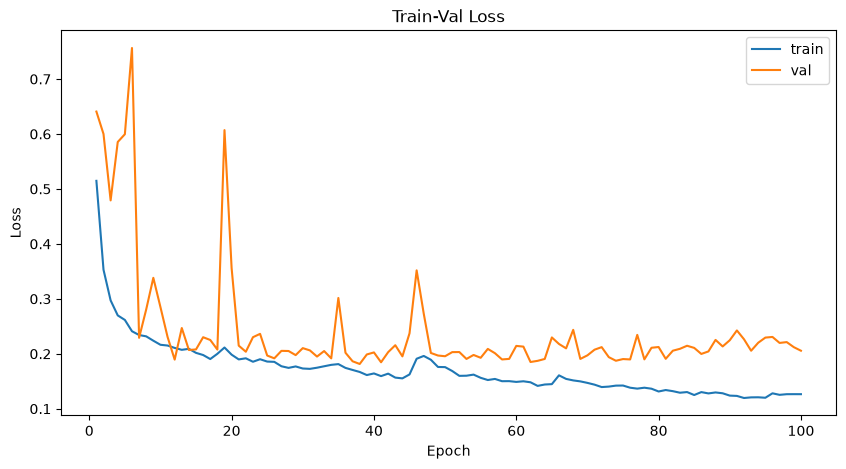

In [115]:
# plot train-val loss
plt.figure(figsize=(10, 5))
plt.title('Train-Val Loss')
plt.plot(range(1, EPOCHS+1), train_loss_hist, label='train')
plt.plot(range(1, EPOCHS+1), val_loss_hist, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. Validation

#### 4.1 Non-ovelap tile strategy

In [116]:
model = UNet(in_ch=1, num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load("best_unet_2.pth", map_location=DEVICE))
model.eval()

UNet(
  (enc1): EncoderBlock(
    (conv): ConvBlock(
      (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): EncoderBlock(
    (conv): ConvBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padd

In [95]:
def compute_metrics(pred, target, num_classes=2, eps=1e-7):
    """
    pred, target: [H, W] (같은 크기의 클래스 인덱스 텐서)
    반환: accuracy(스칼라), 클래스별 dice 리스트, 클래스별 iou 리스트
    """
    correct = (pred == target).sum().item()
    acc = correct / target.numel()

    dices, ious = [], []
    for c in range(num_classes):
        pred_c = (pred == c)
        target_c = (target == c)

        intersection = (pred_c & target_c).sum().item()
        union = (pred_c | target_c).sum().item()
        pred_sum = pred_c.sum().item()
        target_sum = target_c.sum().item()

        dice = (2 * intersection + eps) / (pred_sum + target_sum + eps)
        iou = (intersection + eps) / (union + eps)

        dices.append(dice)
        ious.append(iou)

    return acc, dices, ious


In [65]:
def visualize_prediction(image, gt_mask, pred_mask, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image.squeeze().cpu().numpy(), cmap='gray'); axes[0].set_title("Image")
    axes[1].imshow(gt_mask.cpu().numpy(), cmap='gray');         axes[1].set_title("GT mask")
    axes[2].imshow(pred_mask.cpu().numpy(), cmap='gray');       axes[2].set_title("Prediction")
    for ax in axes:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [117]:
all_acc, all_dice, all_iou = [], [], []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)                                              # [B, C, h_out, w_out]
        masks_cropped = center_crop(masks.unsqueeze(1), outputs.shape[2:]).squeeze(1)  # [B, h_out, w_out]
        preds = outputs.argmax(dim=1)                                        # [B, h_out, w_out]

        for b in range(images.size(0)):
            acc, dices, ious = compute_metrics(preds[b], masks_cropped[b], num_classes=NUM_CLASSES)
            all_acc.append(acc)
            all_dice.append(dices)
            all_iou.append(ious)

all_dice = np.array(all_dice)  # [N, num_classes]
all_iou = np.array(all_iou)    # [N, num_classes]

print(f"평가 이미지 수: {len(all_acc)}")
print(f"평균 accuracy : {np.mean(all_acc):.4f}")
for c in range(NUM_CLASSES):
    print(f"class {c}  mean dice={all_dice[:, c].mean():.4f}  mean iou={all_iou[:, c].mean():.4f}")
print(f"mean dice (전체 클래스 평균): {all_dice.mean():.4f}")
print(f"mean iou  (전체 클래스 평균): {all_iou.mean():.4f}")

평가 이미지 수: 6
평균 accuracy : 0.9177
class 0  mean dice=0.8024  mean iou=0.6703
class 1  mean dice=0.9479  mean iou=0.9010
mean dice (전체 클래스 평균): 0.8752
mean iou  (전체 클래스 평균): 0.7857


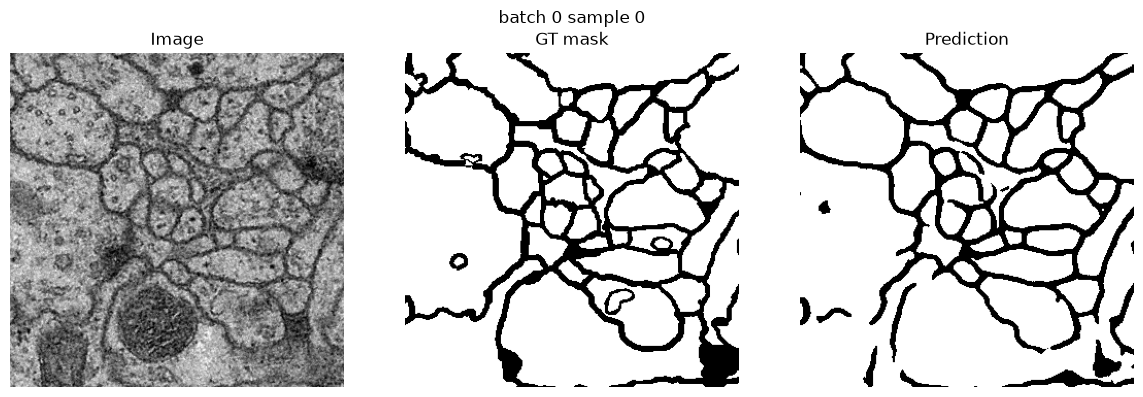

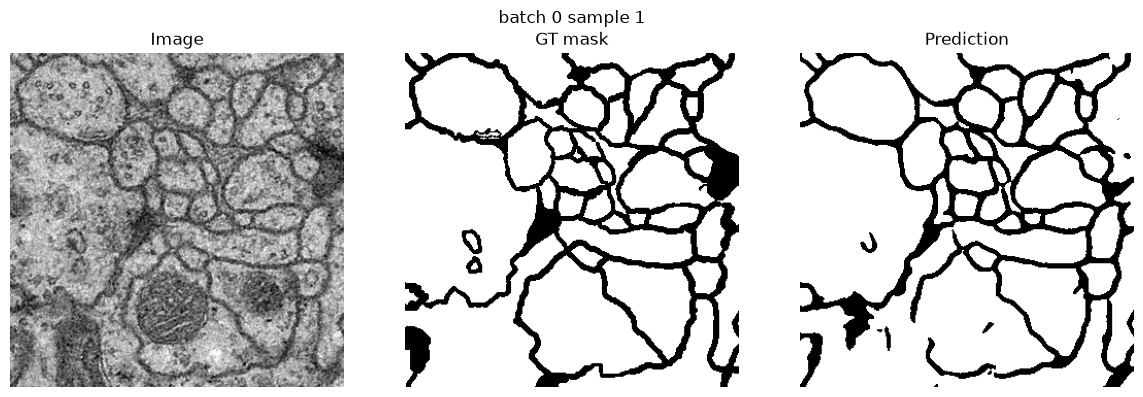

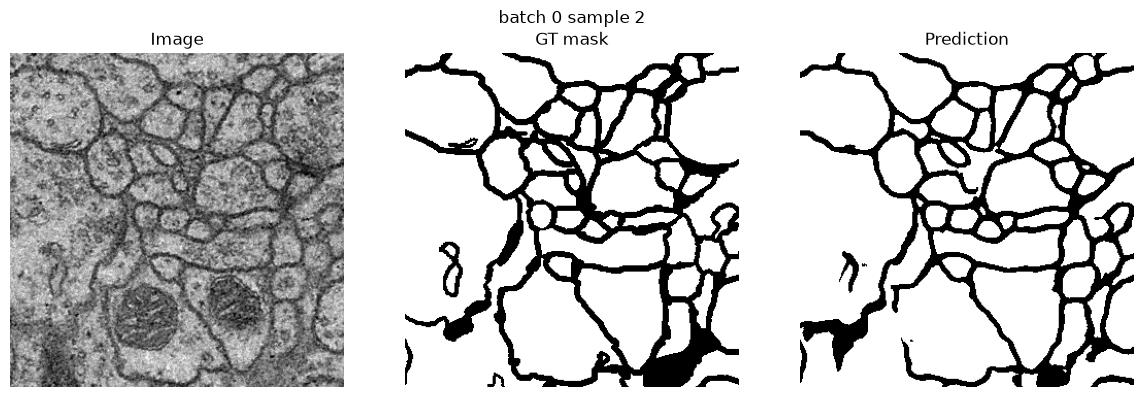

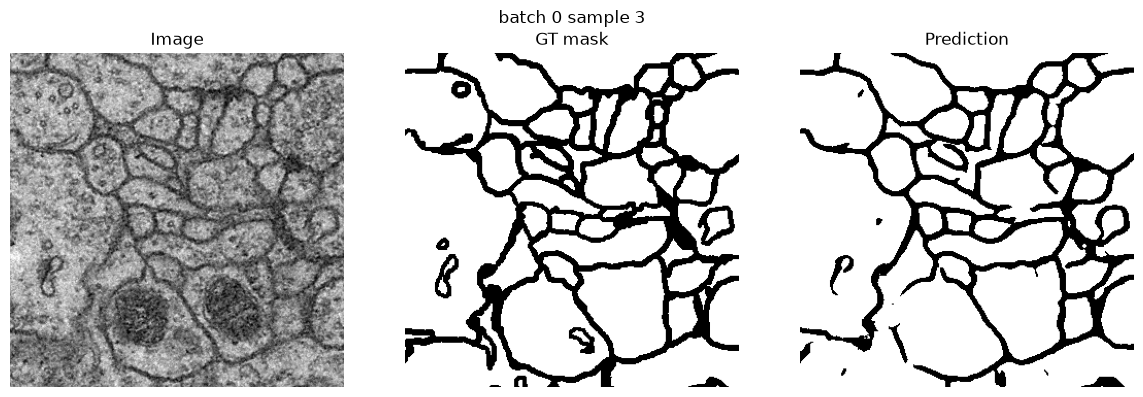

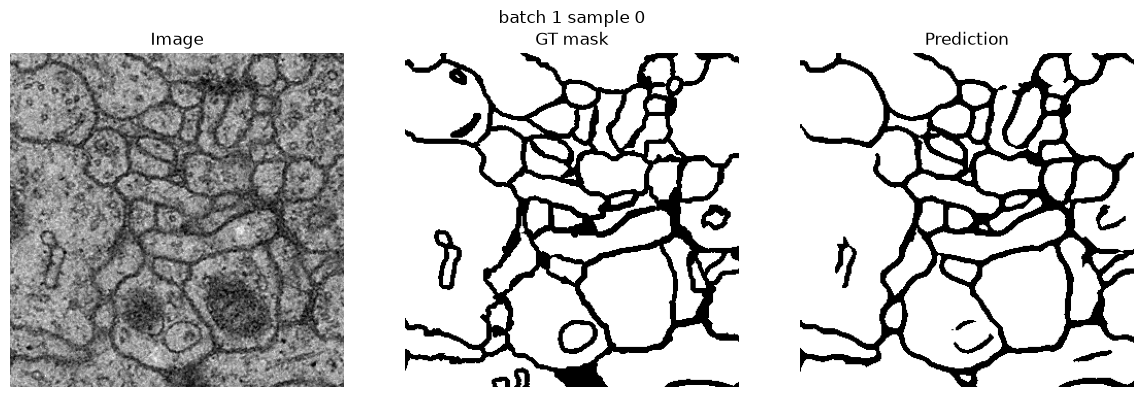

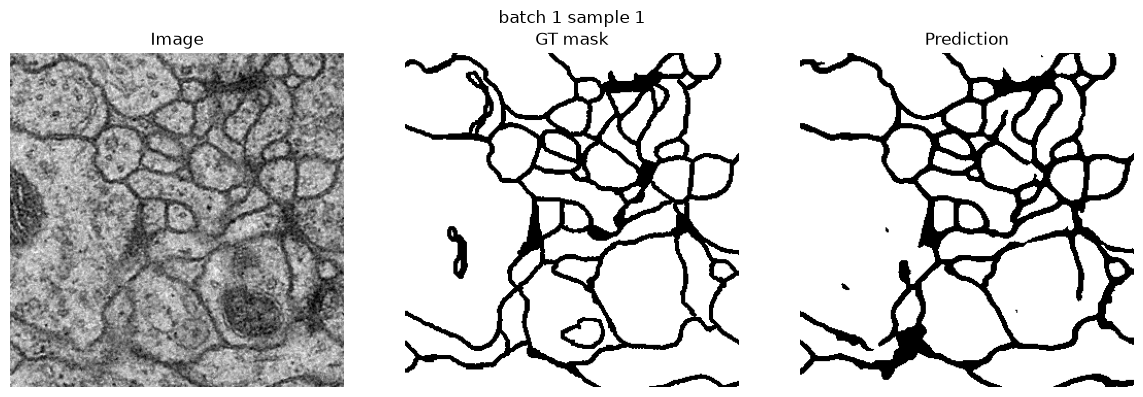

In [118]:
with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)
        masks_cropped = center_crop(masks.unsqueeze(1), outputs.shape[2:]).squeeze(1)
        images_cropped = center_crop(images, outputs.shape[2:])  # 시각화 정렬을 위해 이미지도 같은 크기로 crop
        preds = outputs.argmax(dim=1)

        for b in range(images.size(0)):
            visualize_prediction(images_cropped[b], masks_cropped[b], preds[b], title=f"batch {idx} sample {b}")

        if idx >= 1:  # 처음 두 배치 정도만 시각화(test 5장 전체를 다 보고 싶으면 이 줄 지우면 됨)
            break

#### 4.2 Overlap tile strategy

In [119]:
def get_margin(model, in_size, in_channels=1, device='cpu'):
    """valid conv로 인한 입력-출력 크기 차이(margin)와 실제 출력 크기를 모델로부터 자동 계산"""
    with torch.no_grad():
        dummy = torch.zeros(1, in_channels, in_size, in_size, device=device)
        out = model(dummy)
    out_size = out.shape[-1]
    margin = (in_size - out_size) // 2
    return margin, out_size

In [120]:
def overlap_tile_predict(model, image, in_size=512, device='cpu'):
    model.eval()
    image = image.unsqueeze(0).unsqueeze(0).to(device)
    H, W = image.shape[-2:]

    margin, out_size = get_margin(model, in_size, device=device)
    padded = F.pad(image, (margin, margin, margin, margin), mode='reflect')

    n_tiles_h = -(-H // out_size)
    n_tiles_w = -(-W // out_size)

    output = torch.zeros(1, model.out_conv.out_channels, H, W, device=device)

    for i in range(n_tiles_h):
        for j in range(n_tiles_w):
            y0, x0 = i * out_size, j * out_size

            y0_pad = min(y0, padded.shape[-2] - in_size)
            x0_pad = min(x0, padded.shape[-1] - in_size)

            # 클램프로 인해 실제 시작 위치가 밀린 만큼(offset) 보정
            offset_h = y0 - y0_pad
            offset_w = x0 - x0_pad

            tile = padded[:, :, y0_pad:y0_pad+in_size, x0_pad:x0_pad+in_size]
            with torch.no_grad():
                tile_out = model(tile)

            y1, x1 = min(y0 + out_size, H), min(x0 + out_size, W)
            output[:, :, y0:y1, x0:x1] = tile_out[:, :, offset_h:offset_h+(y1-y0), offset_w:offset_w+(x1-x0)]

    return output


In [121]:
all_acc, all_dice, all_iou = [], [], []
vis_cache = []

for idx in range(len(test_ds)):
    image, mask = test_ds[idx]                 # image: [1, 512, 512], mask: [512, 512]
    image_hw = image.squeeze(0)                 # [512, 512] — overlap_tile_predict 입력 형태에 맞춤

    output = overlap_tile_predict(model, image_hw, in_size=512, device=DEVICE)  # [1, C, 512, 512]
    pred = output.argmax(dim=1).squeeze(0).cpu()  # [512, 512]

    acc, dices, ious = compute_metrics(pred, mask, num_classes=NUM_CLASSES)
    all_acc.append(acc)
    all_dice.append(dices)
    all_iou.append(ious)

    if idx < 5:  # 시각화용으로 몇 개만 저장
        vis_cache.append((image_hw, mask, pred))

all_dice = np.array(all_dice)  # [N, num_classes]
all_iou = np.array(all_iou)    # [N, num_classes]

print(f"평가 이미지 수: {len(all_acc)}")
print(f"평균 accuracy : {np.mean(all_acc):.4f}")
for c in range(NUM_CLASSES):
    print(f"class {c}  mean dice={all_dice[:, c].mean():.4f}  mean iou={all_iou[:, c].mean():.4f}")
print(f"mean dice (전체 평균): {all_dice.mean():.4f}")
print(f"mean iou  (전체 평균): {all_iou.mean():.4f}")

평가 이미지 수: 6
평균 accuracy : 0.9231
class 0  mean dice=0.7939  mean iou=0.6583
class 1  mean dice=0.9527  mean iou=0.9097
mean dice (전체 평균): 0.8733
mean iou  (전체 평균): 0.7840
